# 1. EJEMPLO COMPARATIVO -> IRIS
El dataset Iris es un conjunto de datos que contiene información sobre flores del género Iris, concretamente de 3 especies:

- setosa
- versicolor
- virginica

Cada flor está descrita mediante 4 variables numéricas:

- Longitud del sépalo
- Anchura del sépalo
- Longitud del pétalo
- Anchura del pétalo

Y además tiene una etiqueta (la especie).
Puedes consultar más sobre este dataset en https://archive.ics.uci.edu/dataset/53/iris

En este notebook vamos a comparar dos enfoques distintos:

- un modelo de aprendizaje supervisado, que aprende usando etiquetas reales;
- un modelo K-Means, que agrupa observaciones sin conocer la especie.

La idea es comprobar que ambos pueden generar agrupaciones parecidas, pero no resuelven el mismo problema.

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Cargar Iris

In [86]:
# Mantén este código. En él se carga el Dataset como un Objeto
iris = load_iris()

X = iris.data
y = iris.target

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Nombres de las clases:", iris.target_names)

df = pd.DataFrame(X, columns=iris.feature_names)
df["clase"] = y
df["nombre_clase"] = df["clase"].map({
    0: iris.target_names[0],
    1: iris.target_names[1],
    2: iris.target_names[2]
})

df.head()

Forma de X: (150, 4)
Forma de y: (150,)
Nombres de las clases: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),clase,nombre_clase
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2.1 NOrmalización

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos normalizados (primeras filas):")
print(X_scaled[:5])

Datos normalizados (primeras filas):
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


## 2.2 Método del Codo

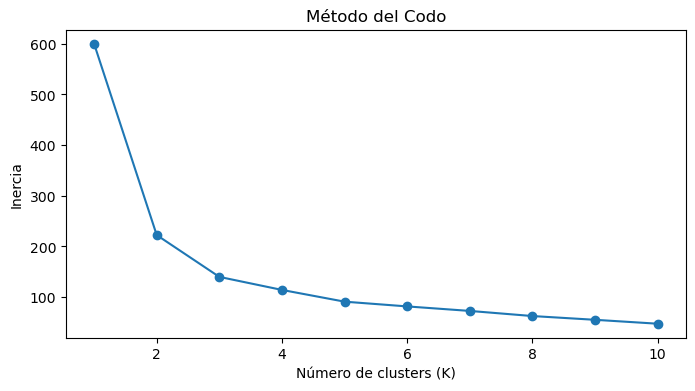

In [88]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled) # X_scaled es el dataset normalizado
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1, 11), inercia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.show()

# 3. Visualización sencilla de dos variables

Para representar el dataset de forma clara, vamos a usar dos variables:

- longitud del pétalo
- anchura del pétalo

Estas variables suelen separar mejor las especies que las medidas del sépalo.

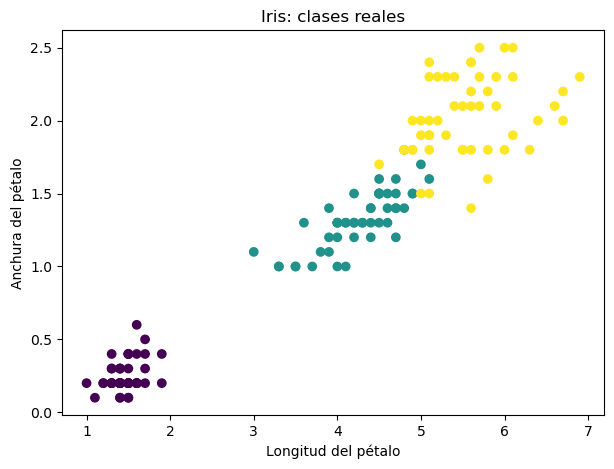

In [89]:
plt.figure(figsize=(7,5))
plt.scatter(X[:, 2], X[:, 3], c=y)
plt.xlabel("Longitud del pétalo")
plt.ylabel("Anchura del pétalo")
plt.title("Iris: clases reales")
plt.show()

# 4. Modelo Supervisado

## 4.1 Interpretación del modelo supervisado

En este caso, el modelo sí conoce las etiquetas reales durante el entrenamiento.

Por eso puede:

- aprender a distinguir especies;
- predecir la clase de nuevas flores;
- comparar sus predicciones con la realidad mediante métricas como la `accuracy` o la matriz de confusión.

In [90]:
# Dividiendo en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Creando modelo de Regresión Logística
modelo_sup = LogisticRegression(n_jobs=-1, C=2)
modelo_sup.fit(X_train, y_train)

# Evaluando modelo
y_pred = modelo_sup.predict(X_test)
y_pred_total = modelo_sup.predict(X_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nInforme de clasificación:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Accuracy: 0.9666666666666667

Matriz de confusión:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Informe de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 4.2 Visualización prediciones supervisadas

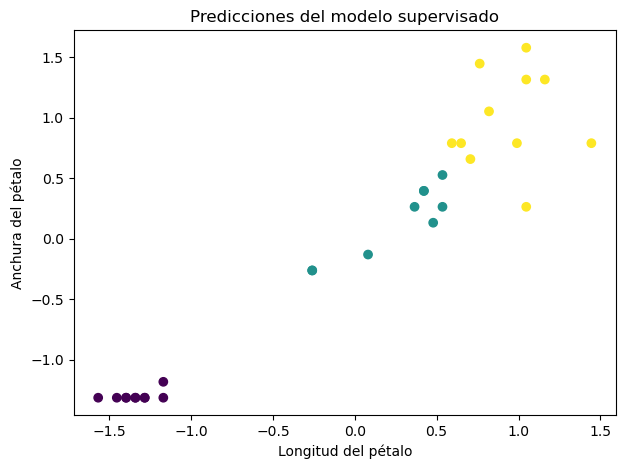

In [91]:
plt.figure(figsize=(7,5))
plt.scatter(X_test[:, 2], X_test[:, 3], c=y_pred)
plt.xlabel("Longitud del pétalo")
plt.ylabel("Anchura del pétalo")
plt.title("Predicciones del modelo supervisado")
plt.show()

# 5. K-Means

Ahora aplicamos **K-Means** sobre el mismo conjunto de datos, pero sin utilizar las etiquetas reales.

Esto significa que el algoritmo:

- no sabe qué flor es setosa, versicolor o virginica;
- solo agrupa observaciones según su similitud.

Por tanto, los clusters obtenidos no tienen por qué coincidir exactamente con las clases reales.

In [92]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
clusters = kmeans.labels_


print("Primeros clusters asignados:", clusters[:20])
print("\nCentroides:")
print(kmeans.cluster_centers_)

Primeros clusters asignados: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Centroides:
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


In [93]:
# tengo que desnormalizar
centroides_originales = scaler.inverse_transform(kmeans.cluster_centers_)

print("Centroides desnormalizados (en cm):")
print(centroides_originales)

Centroides desnormalizados (en cm):
[[5.80188679 2.67358491 4.36981132 1.41320755]
 [5.006      3.428      1.462      0.246     ]
 [6.78085106 3.09574468 5.5106383  1.97234043]]


## 5.1 Visualización K - Means

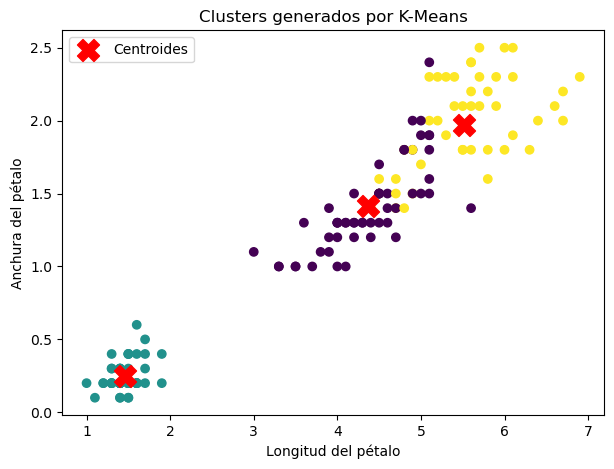

In [94]:
# Tenemos que poder medir en cm. K-Means "ve" datos normalizados; sin emabrgo, estamos representando centímetros
plt.figure(figsize=(7,5))
plt.scatter(X[:, 2], X[:, 3], c=clusters, cmap="viridis")
plt.scatter(
    centroides_originales[:, 2],
    centroides_originales[:, 3],
    c="red",
    marker="X",
    s=250,
    label="Centroides"
)
plt.xlabel("Longitud del pétalo")
plt.ylabel("Anchura del pétalo")
plt.title("Clusters generados por K-Means")
plt.legend()
plt.show()


# 6. Comparación

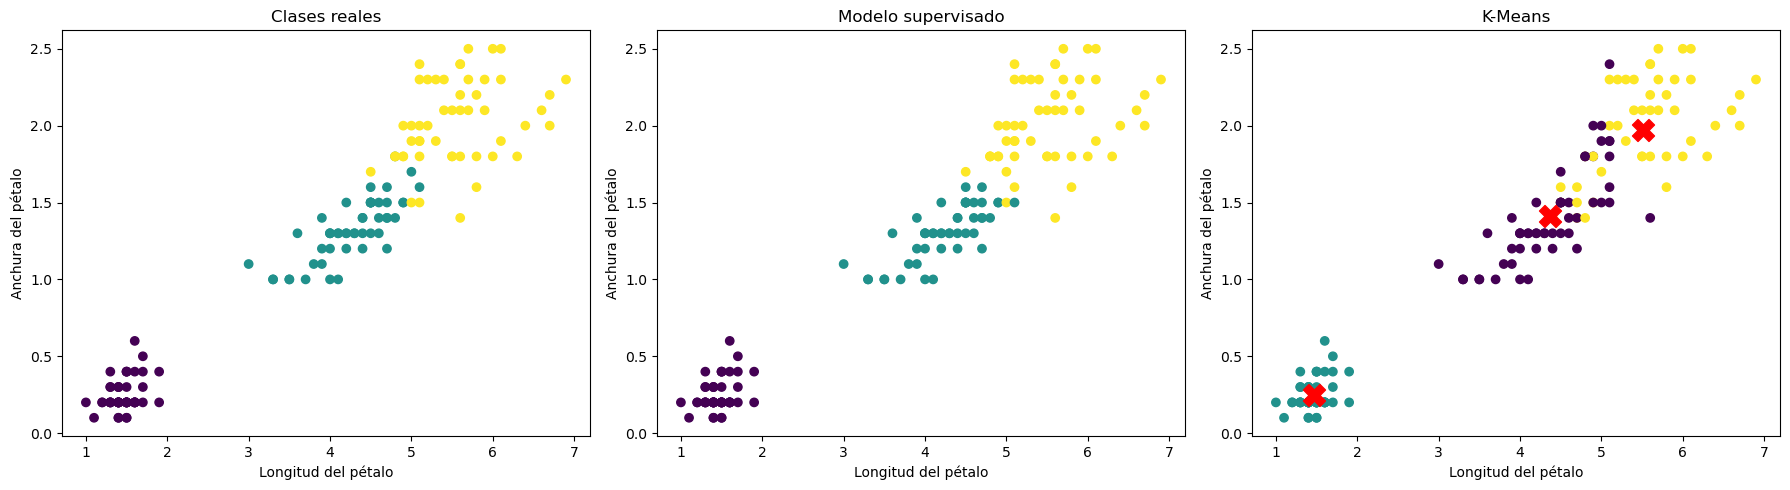

In [95]:
# gráficas que comparan todo lo visto hasta ahora
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mostrando la primera gráfica
axes[0].scatter(X[:, 2], X[:, 3], c=y, cmap="viridis")
axes[0].set_title("Clases reales")
axes[0].set_xlabel("Longitud del pétalo")
axes[0].set_ylabel("Anchura del pétalo")

# Mostrando el modelo supervisado
axes[1].scatter(X[:, 2], X[:, 3], c=y_pred_total, cmap="viridis")
axes[1].set_title("Modelo supervisado")
axes[1].set_xlabel("Longitud del pétalo")
axes[1].set_ylabel("Anchura del pétalo")

# Mostrando el modelo de K-Means
axes[2].scatter(X[:, 2], X[:, 3], c=clusters, cmap="viridis")
axes[2].scatter(
    centroides_originales[:, 2],
    centroides_originales[:, 3],
    c="red",
    marker="X",
    s=250
)
axes[2].set_title("K-Means")
axes[2].set_xlabel("Longitud del pétalo")
axes[2].set_ylabel("Anchura del pétalo")

plt.tight_layout()
plt.show()


# 7. Comparación entre clases reales y clusters

La siguiente tabla permite comparar:

- las clases reales del dataset Iris;
- los grupos generados por K-Means.

Importante:
los números de los clusters no representan directamente las especies.
Por ejemplo, el cluster 0 no tiene por qué corresponder a la clase 0.

Esta tabla sirve para ver qué especies quedan mejor agrupadas y cuáles se mezclan más.

In [ ]:
# Creando la tabla de clases y los grupos generados
tabla_comparacion = pd.crosstab(
    pd.Series(y, name="Clase real"),
    pd.Series(clusters, name="Cluster")
)

tabla_comparacion


Cluster,0,1,2
Clase real,,,
0,0,50,0
1,39,0,11
2,14,0,36


Exception ignored in: <function ResourceTracker.__del__ at 0x78432af8a520>
Traceback (most recent call last):
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ce53dc7e520>
Traceback (most recent call last):
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/ciabd10/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac

# 8. Conclusiones

- El modelo supervisado aprende usando etiquetas reales.
- K-Means no utiliza etiquetas, solo busca agrupaciones por similitud.
- En el dataset Iris, la especie setosa suele quedar muy bien separada.
- Versicolor y virginica presentan más similitud y pueden mezclarse más.
- Un cluster no equivale necesariamente a una clase real.
- otras...

# 9. Cuestiones

1. ¿Por qué el modelo supervisado puede calcular su `accuracy`?
    - El modelo supervisado puede calcular su accuracy porque es capaz de saber de que clase es cada dato, es decir, conoce la etiqueta del dato a diferencia de K-Means que solo busca similitudes
2. ¿Por qué **K-Means** no puede compararse directamente con las clases reales usando solo los números de cluster?
    - K-Means no puede compararse directamente con las clases reales porque no tiene conocimiento explícito de las etiquetas de clase porque es no supervisado. K-Means, clasifica los datos mediante similitudes, por eso el número de clusters son identificadores aleatorios y no corresponden a una clase concreta.
3. ¿Qué especie parece separarse mejor en el dataset Iris?
    - En este dataset, la especie Setosa suele separarse mejor que las otras especies debido a que las características de Setosa tienen una distribución más distintiva en comparación al resto (baja longitud del pétalo y anchura). Las especies Versicolor y Virginica tienen características más solapadas, lo que hace más difícil distinguirlas de manera perfecta.
4. ¿Qué diferencias observas entre clasificar y agrupar?
    - **Clasificar**: se refiere a asignar etiquetas predefinidas a los datos según características aprendidas durante un entrenamiento supervisado
    - **Agrupar**: se refiere a hacer conjuntos de datos en base a las características que comparten los datos
5. ¿En qué casos reales tendría sentido usar un modelo supervisado y en cuáles **K-Means**?
    - **Modelo supervisado**: tiene sentido usarlo cuando se cuenta con datos etiquetados y se necesita predecir o clasificar nuevos datos
    - **K-Means**: es útil cuando no se tiene información previa sobre las categorías o cuando se quiere explorar y entender patrones en los datos